In [1]:
import pandas as pd 
import numpy as np


In [2]:
#q1
df = pd.read_csv('spam.csv')

In [14]:
#q2
df1=df.dropna()

In [15]:
#q3
df_clean = df1.drop_duplicates()

In [17]:
df_clean.columns

Index(['Category', 'Message'], dtype='object')

Text(0, 0.5, 'Frequency')

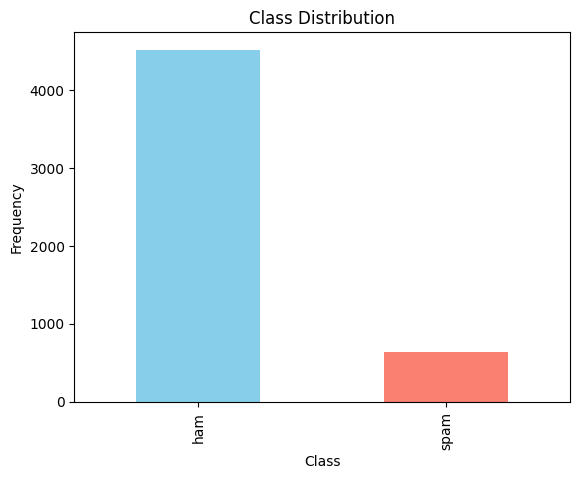

In [19]:
#q4
import matplotlib.pyplot as plt
df_clean['Category'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Frequency')

In [46]:
#q5
import  re
df_clean.loc[:, 'Message'] = df_clean['Message'].apply(lambda x: re.sub(r'\s+', ' ', x))


In [24]:
df_clean

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [47]:
#q6
from bs4 import BeautifulSoup
df_clean.loc[:, 'Message'] = df_clean['Message'].apply(lambda x: BeautifulSoup(x, "html.parser").get_text())


In [48]:
#q7
import unicodedata
def remove_accents(text):
    return ''.join(c for c in unicodedata.normalize('NFD', text) if unicodedata.category(c) != 'Mn')

df_clean.loc[:, 'Message' ]= df_clean['Message'].apply(remove_accents)

In [49]:
# 8. Remove punctuation and special characters
df_clean.loc[:, 'Message'] = df_clean['Message'].apply(lambda x: re.sub(r'[^\w\s]', '', x))


In [32]:

import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\21652\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


True

In [50]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
# 9.supprimer les mots vides
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = word_tokenize(text)
    return ' '.join([word for word in words if word.lower() not in stop_words])

df_clean.loc[:, 'Message'] = df_clean['Message'].apply(remove_stopwords)


In [51]:
#q10
df_clean.loc[:, 'Message'] = df_clean['Message'].str.lower()
#So, df_clean.loc[:, 'Message'] selects all rows from the 'Message' column of the DataFrame df_clean.

In [52]:
#q11
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()

def stem_words(text):
    words = word_tokenize(text)
    return ' '.join([stemmer.stem(word) for word in words])

df_clean.loc[:, 'Message'] = df_clean['Message'].apply(stem_words)

In [36]:
df_clean.head(2)

,Category,Message
0,ham,go jurong point crazy available bugis n great ...
1,ham,ok lar joking wif u oni


In [53]:
#q12
from collections import Counter

# 12. Calculate word frequency and probability of appearance
def calculate_word_frequencies(texts):
    # Tokenize the entire text (assuming 'texts' is a column of text data)
    all_words = ' '.join(texts).split()
    
    # Count the occurrences of each word
    word_count = Counter(all_words)
    
    # Calculate total number of words
    total_words = len(all_words)
    
    # Calculate probabilities and print the results
    for word, count in word_count.items():
        probability = count / total_words
        print(f"Word: {word}, Count: {count}, Probability: {probability:.4f}")

# Apply the function to the text data
calculate_word_frequencies(df_clean['Message'])


Word: go, Count: 436, Probability: 0.0091
Word: jurong, Count: 1, Probability: 0.0000
Word: point, Count: 32, Probability: 0.0007
Word: crazi, Count: 15, Probability: 0.0003
Word: avail, Count: 14, Probability: 0.0003
Word: bugi, Count: 7, Probability: 0.0001
Word: n, Count: 126, Probability: 0.0026
Word: great, Count: 104, Probability: 0.0022
Word: world, Count: 27, Probability: 0.0006
Word: la, Count: 7, Probability: 0.0001
Word: e, Count: 84, Probability: 0.0018
Word: buffet, Count: 2, Probability: 0.0000
Word: cine, Count: 7, Probability: 0.0001
Word: got, Count: 244, Probability: 0.0051
Word: amor, Count: 1, Probability: 0.0000
Word: wat, Count: 105, Probability: 0.0022
Word: ok, Count: 252, Probability: 0.0053
Word: lar, Count: 38, Probability: 0.0008
Word: joke, Count: 14, Probability: 0.0003
Word: wif, Count: 27, Probability: 0.0006
Word: u, Count: 1181, Probability: 0.0246
Word: oni, Count: 4, Probability: 0.0001
Word: free, Count: 238, Probability: 0.0050
Word: entri, Count: 

In [54]:
df_clean.head(5)

,Category,Message
0,ham,go jurong point crazi avail bugi n great world...
1,ham,ok lar joke wif u oni
2,spam,free entri 2 wkli comp win fa cup final tkt 21...
3,ham,u dun say earli hor u c alreadi say
4,ham,nah dont think goe usf live around though
